<a href="https://colab.research.google.com/github/asteriaji/MSSP6070/blob/main/data/Enrollment_Forecast.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Preparing the enviroment

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
%run '/content/drive/MyDrive/Google_connection.py'

Changed directoGit_HUBry to: /content/MSSP-607/MSSP-607


<Figure size 640x480 with 0 Axes>

In [ ]:
pip install openpyxl

In [ ]:
pip install tensorflow

In [ ]:
pip install xlrd

In [ ]:
pip install statsmodels

In [ ]:
pip install matplotlib

In [ ]:
pip install scikit-learn

In [ ]:
pip install pdfkit

In [ ]:
import tensorflow as tf
import keras as ks
import pandas as pd
import numpy as np
import statsmodels
#from statsmodels.tsa.statespace.sarimax import SARIMAX
import os
import openpyxl
import xlrd
import matplotlib.pyplot as plt
%matplotlib inline
import pdfkit

In [ ]:
%pushd "/content/MSSP-607/"

/content/MSSP-607


['/content/MSSP-607/MSSP-607',
 '/content/MSSP-607/MSSP-607',
 '/content/MSSP-607']

# Reading the data

In [ ]:
enrollments = pd.read_csv("/content/MSSP-607/FTUGEnrollments.csv", encoding='utf-8', nrows=23,
                         usecols=[0,1,2])

In [ ]:
enrollments

,Key,Terms,FullTimeUGEnrollments
0,1,Fall 12,2166
1,2,Spring 13,1990
2,3,Fall 13,2080
3,4,Spring 14,1929
4,5,Fall 14,1992
5,6,Spring 15,1763
6,7,Fall 15,1806
7,8,Spring 16,1601
8,9,Fall 16,1500
9,10,Spring 17,1327


In [ ]:
enrollments = pd.read_excel("/content/MSSP-607/FTUGEnrollments.xlsx", nrows=22,
                           usecols=[0,1,2])

In [ ]:
enrollments

,Key,Terms,FullTimeUGEnrollments
0,1,Fall 12,2166
1,2,Spring 13,1990
2,3,Fall 13,2080
3,4,Spring 14,1929
4,5,Fall 14,1992
5,6,Spring 15,1763
6,7,Fall 15,1806
7,8,Spring 16,1601
8,9,Fall 16,1500
9,10,Spring 17,1327


In [ ]:
enrollments.describe()

,Key,FullTimeUGEnrollments
count,22.00,22.00
mean,11.45,1538.68
std,6.44,320.21
min,1.00,1163.00
25%,6.25,1287.25
50%,11.50,1412.50
75%,16.75,1795.25
max,22.00,2166.00


In [ ]:
xlrd_book = xlrd.open_workbook("/content/MSSP-607/ControlCharts.xls", on_demand=True)
with pd.ExcelFile(xlrd_book) as xls:
    df1 = pd.read_excel(xls, "FTUGEnrollments", nrows=22, usecols=[0,1,2], index_col=1, names=["Key", "Term", "FTUGEnrollments"])
    df2 = pd.read_excel(xls, "FTFT UG", nrows=6, usecols=[0,1,2], index_col=1, names=["Key", "Term", "FTUGEnrollments"])
    df3 = pd.read_excel(xls,"TotalGREnrollments", nrows=22, usecols=[0,1,2],index_col=0)

In [ ]:
df1

,Key,FTUGEnrollments
Term,,
Fall 12,1,2166
Spring 13,2,1990
Fall 13,3,2080
Spring 14,4,1929
Fall 14,5,1992
Spring 15,6,1763
Fall 15,7,1806
Spring 16,8,1601
Fall 16,9,1500


In [ ]:
df1["FTUGEnrollments"].describe()

,FTUGEnrollments
count,22.00
mean,1538.68
std,320.21
min,1163.00
25%,1287.25
50%,1412.50
75%,1795.25
max,2166.00


In [ ]:
df2

,Key,FTUGEnrollments
Term,,
Fall 17,1,360
Fall 18,2,421
Fall 19,3,415
Fall 20,4,411
Fall 21,5,358
Fall 22,6,392


In [ ]:
df2["FTUGEnrollments"].describe()

,FTUGEnrollments
count,6.00
mean,392.83
std,27.95
min,358.00
25%,368.00
50%,401.50
75%,414.00
max,421.00


In [ ]:
df3

,Terms,Total GR Enrollments
1,Fall 12,426
2,Spring 13,423
3,Fall 13,383
4,Spring 14,397
5,Fall 14,485
6,Spring 15,457
7,Fall 15,498
8,Spring 16,564
9,Fall 16,733
10,Spring 17,734


In [ ]:
df3.describe()

,Total GR Enrollments
count,22.00
mean,517.59
std,95.56
min,383.00
25%,459.25
50%,487.50
75%,564.00
max,734.00


# Regression modelling

In [ ]:
from statsmodels.tsa.api import ExponentialSmoothing, SimpleExpSmoothing, Holt
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.seasonal import seasonal_decompose

In [ ]:
df1 = df1[df1["Key"] >= 10]
df1["FTUGEnrollments"].values

array([1327, 1413, 1263, 1412, 1274, 1384, 1229, 1441, 1222, 1357, 1212,
       1327, 1163])

In [ ]:
data = np.array(df1["FTUGEnrollments"]).tolist()
index = np.array([
          '2017-06-30',
          '2017-12-31',
          '2018-06-30',
          '2018-12-31',
          '2019-06-30',
          '2019-12-31',
          '2020-06-30',
          '2020-12-31',
          '2021-06-30',
          '2021-12-31',
          '2022-06-30',
          '2022-12-31',
          '2023-06-30'])

In [ ]:
index = pd.DatetimeIndex(index, freq='infer')
index

DatetimeIndex(['2017-06-30', '2017-12-31', '2018-06-30', '2018-12-31',
               '2019-06-30', '2019-12-31', '2020-06-30', '2020-12-31',
               '2021-06-30', '2021-12-31', '2022-06-30', '2022-12-31',
               '2023-06-30'],
              dtype='datetime64[ns]', freq='2QE-DEC')

In [ ]:
aust=pd.DataFrame(data,index, columns=['FTUGEnrollments'])
aust



,FTUGEnrollments
2017-06-30,1327
2017-12-31,1413
2018-06-30,1263
2018-12-31,1412
2019-06-30,1274
2019-12-31,1384
2020-06-30,1229
2020-12-31,1441
2021-06-30,1222
2021-12-31,1357


Figure 1.1: Full Time UG Enrollments between Spring 2017 and Spring 2023.


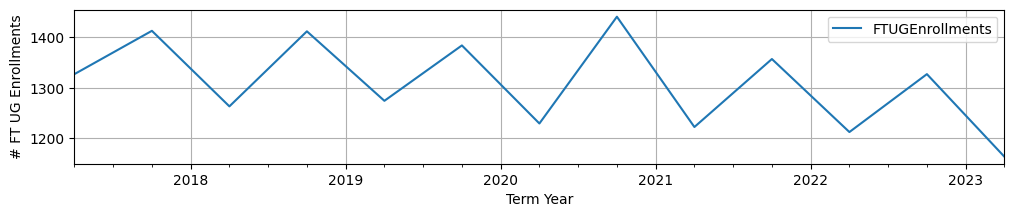

In [ ]:
ax = aust.plot(figsize=(12, 2), grid=True)
ax.set_xlabel("Term Year")
ax.set_ylabel("# FT UG Enrollments")
print("Figure 1.1: Full Time UG Enrollments between Spring 2017 and Spring 2023.")

In [ ]:
fit1 = SimpleExpSmoothing(aust, initialization_method=None).fit(smoothing_level=0.2, optimized=False)
fcast1 = fit1.forecast(6).rename(r"Forecast")
fcast1

,Forecast
2023-12-31,1279.28
2024-06-30,1279.28
2024-12-31,1279.28
2025-06-30,1279.28
2025-12-31,1279.28
2026-06-30,1279.28


Figure 1.2: FRCST: Full Time UG Enrollments between Spring 2017 and Spring 2026.


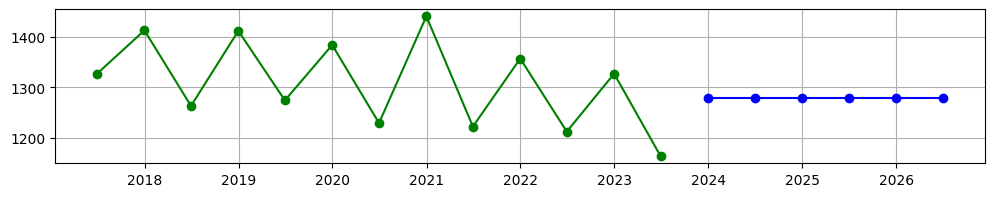

In [ ]:
plt.figure(figsize=(12, 2))
plt.grid(True)
plt.plot(aust, marker='o', color='green')
plt.plot(fcast1, marker="o", color="blue")
print("Figure 1.2: FRCST: Full Time UG Enrollments between Spring 2017 and Spring 2026.")

In [ ]:
print(fit1.summary())

                       SimpleExpSmoothing Model Results                       
Dep. Variable:        FTUGEnrollments   No. Observations:                   13
Model:             SimpleExpSmoothing   SSE                         107398.846
Optimized:                      False   AIC                            121.252
Trend:                           None   BIC                            122.382
Seasonal:                        None   AICC                           126.252
Seasonal Periods:                None   Date:                 Thu, 30 Oct 2025
Box-Cox:                        False   Time:                         17:50:39
Box-Cox Coeff.:                  None                                         
                       coeff                 code              optimized      
------------------------------------------------------------------------------
smoothing_level            0.2000000                alpha                False
initial_level              1327.0000                

In [ ]:
fit2 = ExponentialSmoothing(aust, seasonal=None, trend=None).fit(optimized=True)


In [ ]:
fcast2 = fit2.forecast(6).rename(r"Forecast")
fcast2

,Forecast
2023-12-31,1309.54
2024-06-30,1309.54
2024-12-31,1309.54
2025-06-30,1309.54
2025-12-31,1309.54
2026-06-30,1309.54


In [ ]:
print(fit2.summary())

                       ExponentialSmoothing Model Results                       
Dep. Variable:          FTUGEnrollments   No. Observations:                   13
Model:             ExponentialSmoothing   SSE                          95457.232
Optimized:                         True   AIC                            119.719
Trend:                             None   BIC                            120.849
Seasonal:                          None   AICC                           124.719
Seasonal Periods:                  None   Date:                 Thu, 30 Oct 2025
Box-Cox:                          False   Time:                         17:50:39
Box-Cox Coeff.:                    None                                         
                       coeff                 code              optimized      
------------------------------------------------------------------------------
smoothing_level           1.4901e-08                alpha                 True
initial_level              1309.53

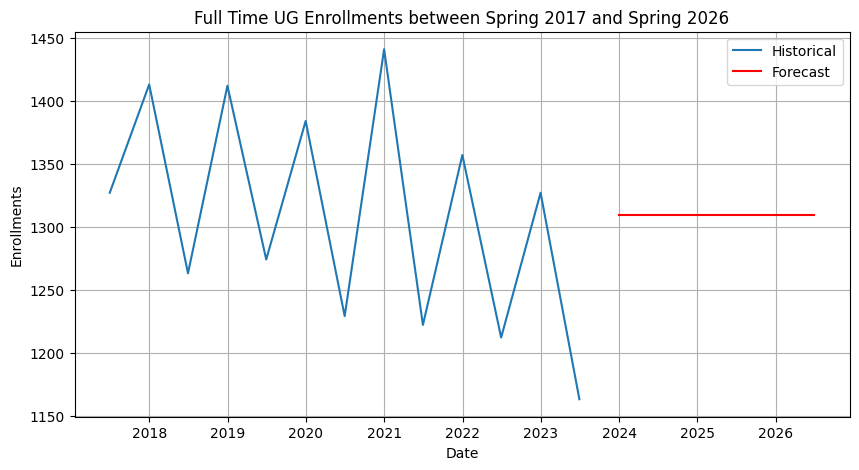

In [ ]:
plt.figure(figsize=(10, 5))
plt.grid(True)
plt.plot(aust.index, aust, label='Historical')
plt.plot(fcast2.index, fcast2, label='Forecast', color='red')
plt.title('Full Time UG Enrollments between Spring 2017 and Spring 2026')
plt.xlabel('Date')
plt.ylabel('Enrollments')
plt.legend()
plt.show()

In [ ]:
fit3 = Holt(aust, initialization_method=None).fit(smoothing_level=0.8, smoothing_trend=0.2, optimized=False)
fcast3 = fit3.forecast(6).rename(r"$\alpha=0.2$")

Figure 1.3: FRCST: Full Time UG Enrollments between Spring 2017 and Spring 2026.


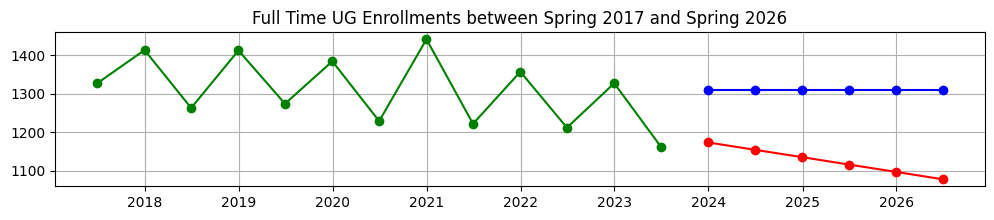

In [ ]:
plt.figure(figsize=(12, 2))
plt.grid(True)
plt.plot(aust, marker='o', color='green')
plt.plot(fcast2, marker="o", color="blue")
plt.plot(fcast3, marker="o", color="red")
plt.title('Full Time UG Enrollments between Spring 2017 and Spring 2026')
plt.savefig('Forecast 3.pdf')
print("Figure 1.3: FRCST: Full Time UG Enrollments between Spring 2017 and Spring 2026.")

In [ ]:
print(fit3.summary())

                              Holt Model Results                              
Dep. Variable:        FTUGEnrollments   No. Observations:                   13
Model:                           Holt   SSE                         260267.145
Optimized:                      False   AIC                            136.759
Trend:                       Additive   BIC                            139.018
Seasonal:                        None   AICC                           150.759
Seasonal Periods:                None   Date:                 Thu, 30 Oct 2025
Box-Cox:                        False   Time:                         17:50:40
Box-Cox Coeff.:                  None                                         
                       coeff                 code              optimized      
------------------------------------------------------------------------------
smoothing_level            0.8000000                alpha                False
smoothing_trend            0.2000000                

In [ ]:
fcast3

,$\alpha=0.2$
2023-12-31,1173.71
2024-06-30,1154.61
2024-12-31,1135.52
2025-06-30,1116.43
2025-12-31,1097.34
2026-06-30,1078.25


                               SARIMAX Results                                
Dep. Variable:        FTUGEnrollments   No. Observations:                   13
Model:                 ARIMA(3, 1, 1)   Log Likelihood                 -62.377
Date:                Thu, 30 Oct 2025   AIC                            134.753
Time:                        17:50:40   BIC                            137.178
Sample:                    06-30-2017   HQIC                           133.856
                         - 06-30-2023                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -1.4236      0.565     -2.521      0.012      -2.531      -0.317
ar.L2         -0.7700      0.808     -0.952      0.341      -2.354       0.814
ar.L3         -0.3432      0.401     -0.857      0.3

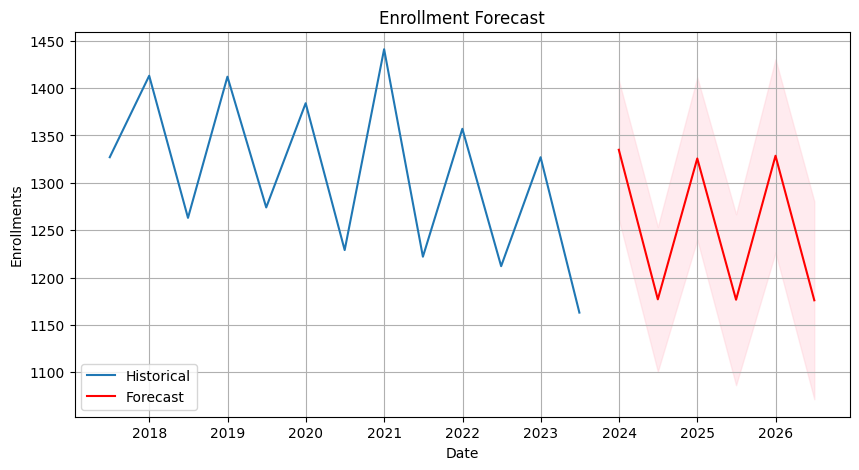

In [ ]:
#In ARIMA (AutoRegressive Integrated Moving Average) models, the parameters (p, d, q)
#define how the model handles autocorrelation, trend (non-stationarity), and noise smoothing.
#p=Autoregressive order; Represents how many past observations (lags) are used to predict the current value.
#d=Differencing order;Represents how many times the data is differenced to make it stationary (i.e., remove trends).
#q=Moving average;Represents how many past forecast errors (residuals) are used to predict the current value.

#smaller AIC means a better balance of fit vs. parsimony; Parsimony means simplicity in a model — but not oversimplification.

model = ARIMA(aust, order=(3, 1, 1))  # Example parameters: p=1, d=1, q=1
fitted_model = model.fit()

print(fitted_model.summary())

forecast=fitted_model.get_forecast(steps=6)
forecast_df = forecast.summary_frame()
forecast_df

plt.figure(figsize=(10, 5))
plt.grid(True)
plt.plot(aust.index, aust, label='Historical')
plt.plot(forecast_df.index, forecast_df['mean'], label='Forecast', color='red')
plt.fill_between(forecast_df.index, forecast_df['mean_ci_lower'], forecast_df['mean_ci_upper'], color='pink', alpha=0.3)
plt.title('Enrollment Forecast')
plt.xlabel('Date')
plt.ylabel('Enrollments')
plt.legend()
plt.show()


In [ ]:
forecast_df

FTUGEnrollments,mean,mean_se,mean_ci_lower,mean_ci_upper
2023-12-31,1334.86,37.39,1261.57,1408.15
2024-06-30,1177.01,38.90,1100.77,1253.25
2024-12-31,1325.68,43.69,1240.05,1411.32
2025-06-30,1176.59,46.05,1086.33,1266.84
2025-12-31,1328.54,52.05,1226.53,1430.55
2026-06-30,1175.99,53.28,1071.57,1280.42


## SARIMA Modelling; seasonal AutoRegressive Integrated Moving Average extends the ARIMA model to handle seasonal patterns in time-series data — such as quarterly sales, monthly temperature cycles, or weekly website traffic

When ACF/PACF scream “strong seasonality,” you typically want seasonal differencing and possibly stronger seasonal AR/MA terms, while avoiding over-differencing.

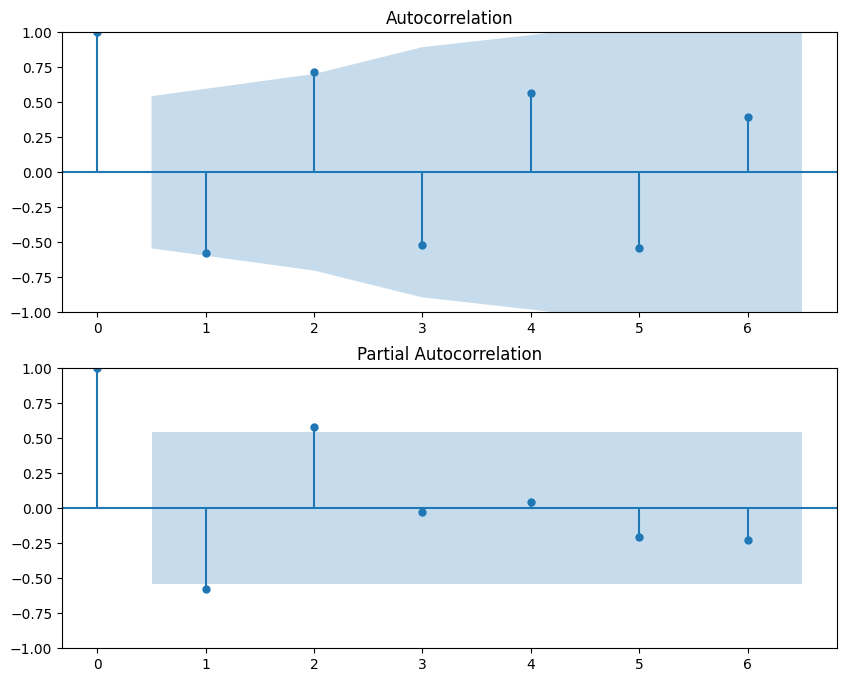

In [ ]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# Plot ACF and PACF to help determine SARIMA orders
fig, axes = plt.subplots(2, 1, figsize=(10, 8))
plot_acf(aust, ax=axes[0])
plot_pacf(aust, ax=axes[1])
plt.show()

Based on the ACF and PACF plots, we can try fitting a SARIMA model. Let's start with some common initial orders.

In [ ]:
# Fit a SARIMA model
# You might need to adjust the order (p, d, q) and seasonal_order (P, D, Q, S) based on the ACF/PACF plots and model diagnostics
#seasonal order defines how the model captures repeating seasonal patterns in your time series (such as monthly, quarterly, or weekly cycles).

model = SARIMAX(aust, order=(3,1 ,1), seasonal_order=(1, 1, 1, 5), trend='n')
sarima_fit = model.fit(disp=False)

sarima_fcast=sarima_fit.get_forecast(steps=6)
sarima_fcast_df = forecast.summary_frame()


print(sarima_fit.summary())

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'


                                     SARIMAX Results                                     
Dep. Variable:                   FTUGEnrollments   No. Observations:                   13
Model:             SARIMAX(3, 1, 1)x(1, 1, 1, 5)   Log Likelihood                 -37.249
Date:                           Thu, 30 Oct 2025   AIC                             88.497
Time:                                   17:52:01   BIC                             88.119
Sample:                               06-30-2017   HQIC                            83.817
                                    - 06-30-2023                                         
Covariance Type:                             opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -1.0713      1.508     -0.710      0.477      -4.027       1.884
ar.L2         -0.9029      3.197     -0.282

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [ ]:
sarima_fcast_df

FTUGEnrollments,mean,mean_se,mean_ci_lower,mean_ci_upper
2023-12-31,1288.54,10.97,1267.05,1310.04
2024-06-30,1167.61,14.77,1138.66,1196.56
2024-12-31,1295.38,14.76,1266.45,1324.31
2025-06-30,1117.99,14.98,1088.63,1147.34
2025-12-31,1315.75,17.56,1281.33,1350.18
2026-06-30,1117.11,17.35,1083.10,1151.12


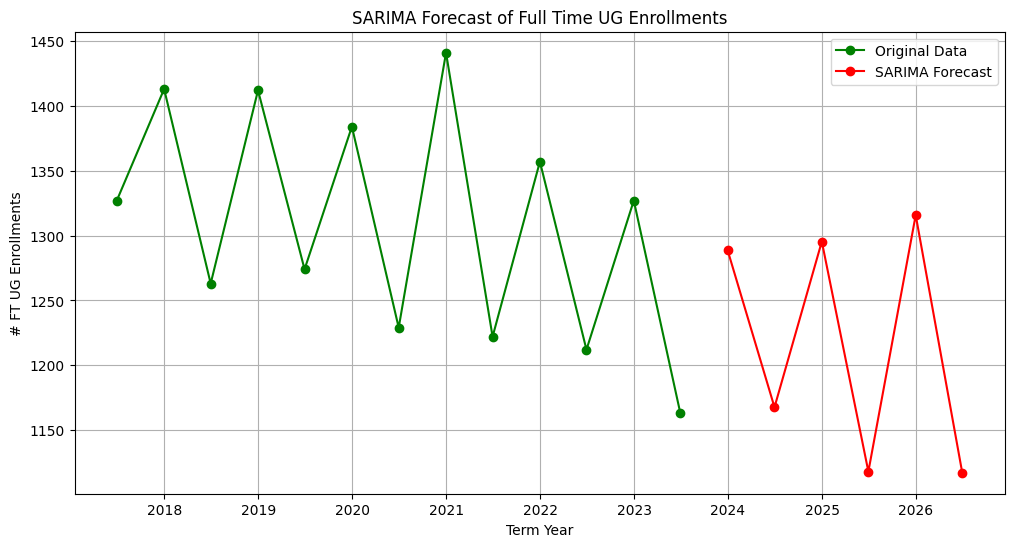

In [ ]:
# Forecast future values
sarima_fcast = sarima_fit.forecast(6)

# Plot the original data and the SARIMA forecast
plt.figure(figsize=(12, 6))
plt.plot(aust, marker='o', color='green', label='Original Data')
plt.plot(sarima_fcast, marker="o", color="red", label='SARIMA Forecast')
plt.title('SARIMA Forecast of Full Time UG Enrollments')
plt.xlabel('Term Year')
plt.ylabel('# FT UG Enrollments')
plt.grid(True)
plt.legend()
plt.show()